                 Linear regression_ employee data set

Problem statement/Task: Implement machine learning model (linear regression) on employe data (historical data)  and predict employee salary
Domain: company employee

Step 1: import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

step 2: Load employee data file and store it in dataframe emp

In [2]:
emp=pd.read_csv("employee.xls")

Step 3: display dataframe

In [3]:
emp

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


By observing historical data it is observed that:
1. Target variable is labelled i.e. salary so supervised ML algorithm can be applied.
2. Target variable has continuous/numerical data therefore regression algorithm can be applied.

Step 4: understanding data or EDA or Feature engineering or data pre-processing 

In [4]:
#4.1 : display top 5 records:
emp.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [5]:
#4.2: Display number of dimensions of data
emp.ndim

2

In [6]:
#4.3: Display no. of rows and columns of dataframe
emp.shape

(30, 2)

In ML Rows are called Records/entries/samples, and columns are called as features/variables

In [7]:
#4.4 : Display total records or samples or data points of the data frame
emp.size   #size=rows*columns

60

In [8]:
#4.5: Display each column information
emp.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [9]:
#4.6: Display statistical measures of the numeric columns
emp.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [10]:
#4.7: display correlation between experience and salary
emp.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


In [11]:
#OR
print(emp['YearsExperience'].corr(emp['Salary']))

0.9782416184887599


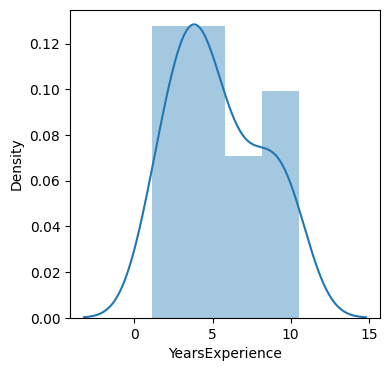

In [12]:
#4.8: Display distribution of variables (normal distribution=bell curve)
plt.figure(figsize=(4,4))
sns.distplot(emp['YearsExperience'])
plt.show()

Inference : YearsExperience is positive skewed or right skewed distribution. 
    positive skewed : mean>mode>median

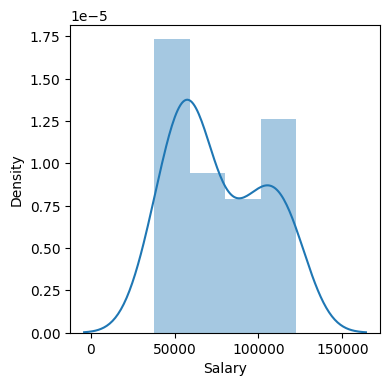

In [13]:
plt.figure(figsize=(4,4))
sns.distplot(emp['Salary'])
plt.show()

Above is also positive skewed

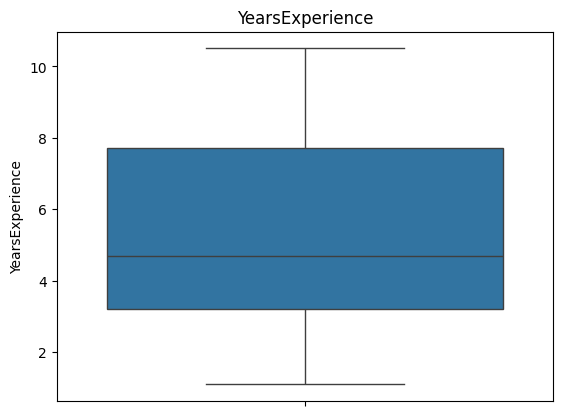

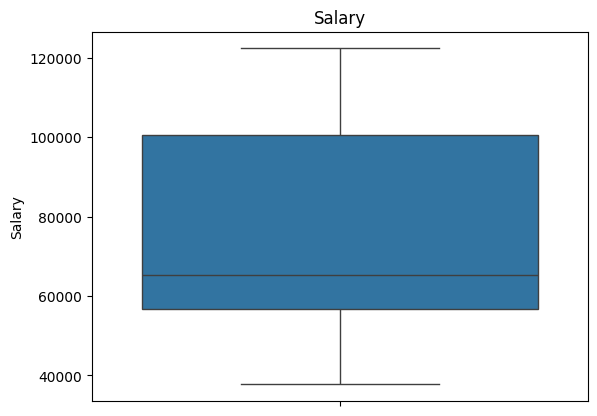

In [14]:
#4.9: Check outliers (using box plot)
#outliers are checked for numeric columns only
for i in emp.columns:
    if(emp[i].dtype!='object'):
        sns.boxplot(emp[i])
        plt.title(i)
        plt.show()

Inference : NO outliers present.

In [ ]:
#4.10: Encoding: converting object columns to numeric columns
#since all columns of data frame are numeric hence no encoding in this case id required.

In [15]:
#4.11 : split/divide data frame into independent features i.e. x independent feature i.e. y/target variable

x= Input/independent variable
y= output/target/dependent variable

In [16]:
x=emp[['YearsExperience']]  # x should be 2d data structure
x

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [17]:
x.shape

(30, 1)

In [18]:
x.ndim

2

In [19]:
y=emp['Salary']       # y must be 1d data
y

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64

In [20]:
y.shape

(30,)

In [21]:
y.ndim

1

4.12 : Split x and y into train data and test data
       train data size = 70% of overall data size
       test data size = 30% of overall data size    
(By above information total data size is 60 therefore, 42(i.e. 21 for x_train and 21 for y_train) data points for train data and 18 (i.e. 9 for x_test and 9 for y_test) for test data)

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,random_state=42)
print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

x_train shape: (21, 1)
x_test shape: (9, 1)
y_train shape: (21,)
y_test shape: (9,)


Now upto here data pre-processing is completed

5. Apply ML model (Linear regression) algorithm on train data    (#sklearn is a machine learning library which contains all requirements for ML)

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
model=LinearRegression()
model.fit(x_train,y_train)    #model fitted or applied on train data

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
#display model parameters:Regression coefficient (slope,m), Regression intersept (c)
print("Regression Coefficient:",model.coef_)
print("Regression Intercept:",model.intercept_)

Regression Coefficient: [9339.08172382]
Regression Intercept: 25918.438334893202


6. Test model or predict model output by applying testing data

In [28]:
y_pred=model.predict(x_test)

7. Display actual output and model output

In [32]:
res=pd.DataFrame()
res['Actual_salary']=y_test
res['Predicted_salary']=y_pred
res['error']=y_test-y_pred
res['square of error']=(y_test-y_pred)**2
res

,Actual_salary,Predicted_salary,error,square of error
27,112635.0,115573.622884,-2938.622884,8.635504e+06
15,67938.0,71679.938782,-3741.938782,1.400211e+07
23,113812.0,102498.908470,11313.091530,1.279860e+08
17,83088.0,75415.571471,7672.428529,5.886616e+07
8,64445.0,55803.499851,8641.500149,7.467552e+07
9,57189.0,60473.040713,-3284.040713,1.078492e+07
28,122391.0,122110.980090,280.019910,7.841115e+04
24,109431.0,107168.449332,2262.550668,5.119136e+06
12,56957.0,63274.765230,-6317.765230,3.991416e+07


8. Performace evaluation of linear regression ML model.
    i) plot the regression response
    ii) quantitative measures (MSE,MAE,RMSE,R2_score)

8.1 plot the regression response (scatter plot and line plot)

In [33]:
p1=min(min(y_test),min(y_pred))
p2=max(max(y_test),max(y_pred))

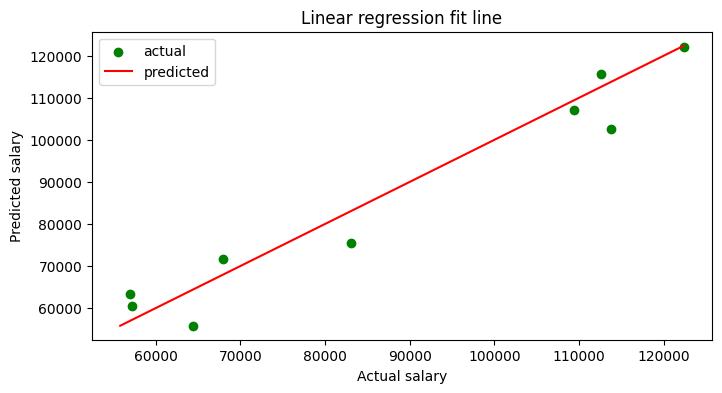

In [39]:
plt.figure(figsize=(8,4))
plt.scatter(y_test,y_pred,color='green',label='actual')
plt.plot([p1,p2],[p1,p2],color='red',label='predicted')
plt.legend()
plt.xlabel("Actual salary")
plt.ylabel("Predicted salary")
plt.title("Linear regression fit line")
plt.show()


8.2 : quantitative measures (MSE,MAE,RMSE,R2_score)

In [40]:
from sklearn.metrics import *

In [41]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2_score=r2_score(y_test,y_pred)

In [43]:
print("Mean square error(MSE):",mse)
print("Mean absolute error(MAE):",mae)
print("Root mean square error(RMSE):",rmse)
print("R2 score:",r2_score)

Mean square error(MSE): 37784662.46621314
Mean absolute error(MAE): 5161.328710400183
Root mean square error(RMSE): 6146.92300799458
R2 score: 0.9414466227178214


9. Apply new sample and predict output 
if employee experience is 11.8 years predict/guess employee salary.

In [44]:
new_sample=[[11.8]]
pred=model.predict(new_sample)
print("Predicted salary:",pred)

Predicted salary: [136119.60267591]


10. Apply new sample and predict output 
if employee experience is 6.0 years predict/guess employee salary.

In [45]:
new_sample=[[6.0]]
pred=model.predict(new_sample)
print("Predicted salary:",pred)

Predicted salary: [81952.92867778]
